# Music box: from a high-speed video to the notes of a steel comb

This notebook identifies the vibration of the teeth of a mechanical music box from a
high-speed video, using `pyidi`. The recording is not shipped with the package; it is
downloaded from Zenodo on the first run:

> Stanovnik, G., & Slavič, J. (2026). *High-speed video of a vibrating music-box comb
> (Photron FASTCAM SA-Z, 7500 fps, 640x552 px)* [Data set]. Zenodo.
> [10.5281/zenodo.22105821](https://doi.org/10.5281/zenodo.22105821) (CC BY 4.0)

The comb is a row of steel cantilevers of graduated length. A tooth that has been plucked
by a pin of the rotating cylinder rings at its own natural frequencies until it is damped
out. Seen by the camera, the teeth move by a few pixels at most and, near the root, by a
few hundredths of a pixel — which is exactly what image-based displacement identification
is for.

What follows: open the recording, look at where it moves, track 15 teeth with the
Lucas-Kanade method, read the note of every tooth from the spectrum of its displacement,
and measure the deflection shape along a single tooth.

## 1. Open the recording

`pyidi.datasets.load_music_box` downloads the frames it needs (600 frames, 405 MiB, by
default), caches them in `~/.pyidi/datasets` and returns an ordinary `VideoReader`. Set
`PYIDI_DATA_DIR` to cache the data somewhere else. The next run reads the cache and is
instant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyidi

video = pyidi.datasets.load_music_box()   # n_frames=600, first_frame=400

In [2]:
fps = video.fps
print(f'{video.N} frames of {video.image_width} x {video.image_height} px at {fps:.0f} fps')
print(f'duration: {video.N / fps * 1000:.1f} ms, Nyquist frequency: {fps / 2:.0f} Hz')
print(f"camera: {video.info['Camera Type']}, {video.info['EffectiveBit Depth']}-bit")

600 frames of 640 x 552 px at 7500 fps
duration: 80.0 ms, Nyquist frequency: 3750 Hz
camera: FASTCAM SA-Z type 2100K-M-64GB, 12-bit


## 2. What is in the frame

The camera looks down on the comb and the teeth run horizontally across the image. The
dark horizontal lines are the slots between the teeth, spaced about 22 px apart. A slot
ends where the tooth meets the solid base of the comb — the staircase in the left half of
the image — so each tooth is a cantilever clamped on the left and free on the right, at
x ≈ 560 px. The teeth get shorter towards the bottom of the image, and their notes get
higher.

The surface of the steel is naturally speckled, which is what makes sub-pixel tracking
possible without any applied pattern.

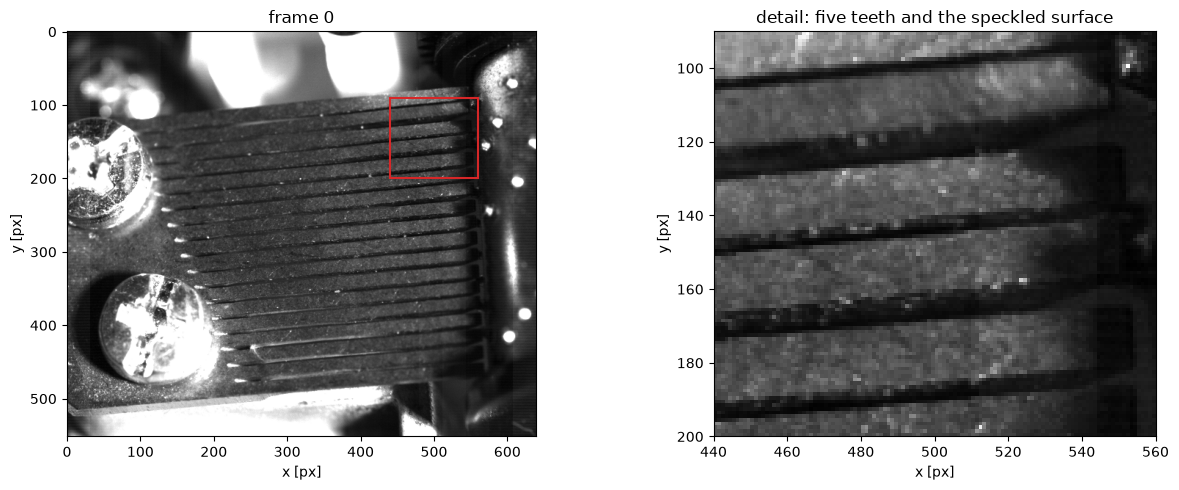

In [3]:
reference = np.asarray(video.get_frame(0))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(reference, cmap='gray')
ax[0].add_patch(plt.Rectangle((440, 90), 120, 110, fill=False, color='tab:red', lw=1.5))
ax[0].set_title('frame 0')
ax[0].set_xlabel('x [px]'); ax[0].set_ylabel('y [px]')

ax[1].imshow(reference[90:200, 440:560], cmap='gray',
             extent=(440, 560, 200, 90), interpolation='nearest')
ax[1].set_title('detail: five teeth and the speckled surface')
ax[1].set_xlabel('x [px]'); ax[1].set_ylabel('y [px]')
plt.tight_layout()

## 3. Where does it move?

Before tracking anything, a map of the temporal standard deviation of the image intensity
shows where the image changes at all. It costs one pass over the frames and needs no
method: bright bands appear along the edges of the teeth that are ringing.

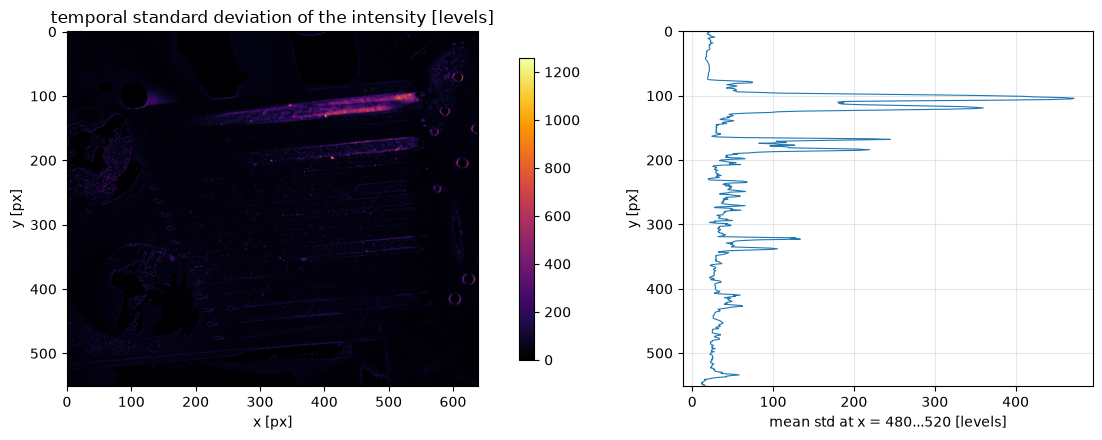

In [4]:
frames = np.asarray(video.get_frames((0, 200))).astype(np.float32)
motion = frames.std(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), width_ratios=(2, 1))
image = ax[0].imshow(motion, cmap='inferno')
ax[0].set_title('temporal standard deviation of the intensity [levels]')
ax[0].set_xlabel('x [px]'); ax[0].set_ylabel('y [px]')
plt.colorbar(image, ax=ax[0], shrink=0.85)

ax[1].plot(motion[:, 480:520].mean(axis=1), np.arange(video.image_height), lw=0.8)
ax[1].set_ylim(video.image_height, 0)
ax[1].set_xlabel('mean std at x = 480...520 [levels]'); ax[1].set_ylabel('y [px]')
ax[1].grid(alpha=0.3)
plt.tight_layout()

del frames

Two teeth stand out. In this window of the recording they are the ones that ring
loudly; the others are much quieter, but as the spectra below show, they are not silent —
the comb is a single piece of steel and its base couples the teeth to each other.

## 4. Where to measure

One point per tooth, at `x = 500`, i.e. close to the free end where the amplitude is
largest but still on the textured surface. The teeth are 22 px apart and the first one is
at `y = 109`; in `pyidi` a point is given as `(row, column) = (y, x)`.

The region of interest is 21 px tall and 51 px wide: one tooth tall, so that a neighbouring
tooth moving differently cannot pull the result, and wide enough to contain plenty of
texture. A region much taller than a tooth averages the teeth together; a much shorter one
is easily confused by the 22 px periodicity of the comb.

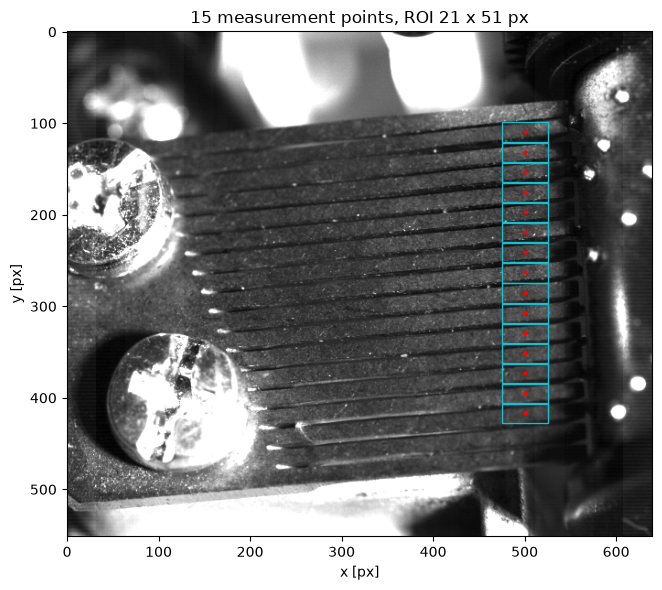

In [5]:
tooth_rows = np.arange(109, 420, 22)     # 15 teeth
column = 500
roi_size = (21, 51)                      # (height, width) in px

points = np.array([[row, column] for row in tooth_rows])

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(reference, cmap='gray')
for row in tooth_rows:
    ax.add_patch(plt.Rectangle((column - roi_size[1] // 2, row - roi_size[0] // 2),
                               roi_size[1], roi_size[0], fill=False, color='tab:cyan', lw=1))
ax.plot(points[:, 1], points[:, 0], 'r.', ms=4)
ax.set_title(f'{len(points)} measurement points, ROI {roi_size[0]} x {roi_size[1]} px')
ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
plt.tight_layout()

## 5. Lucas-Kanade

`LucasKanade` finds the translation of every region of interest with respect to the
reference image, with sub-pixel resolution. Since version 1.4.0 the inner loop is compiled
and parallelized over points, so this run takes about a second.

In [6]:
lk = pyidi.LucasKanade(video)
lk.set_points(points)
lk.configure(roi_size=roi_size, pad=3, int_order=3, reference_image=0, show_pbar=False)

displacements = lk.get_displacements(autosave=False)
displacements.shape     # (point, frame, direction), direction 0 is y, 1 is x

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.00 s


Time to complete: 0.4 s


(15, 600, 2)

## 6. The teeth ringing

The teeth move out of plane; in this view the projection of that motion is dominantly
vertical, so the y-direction is the interesting one. The histories below are stacked with
an offset, the loudest tooth at the top.

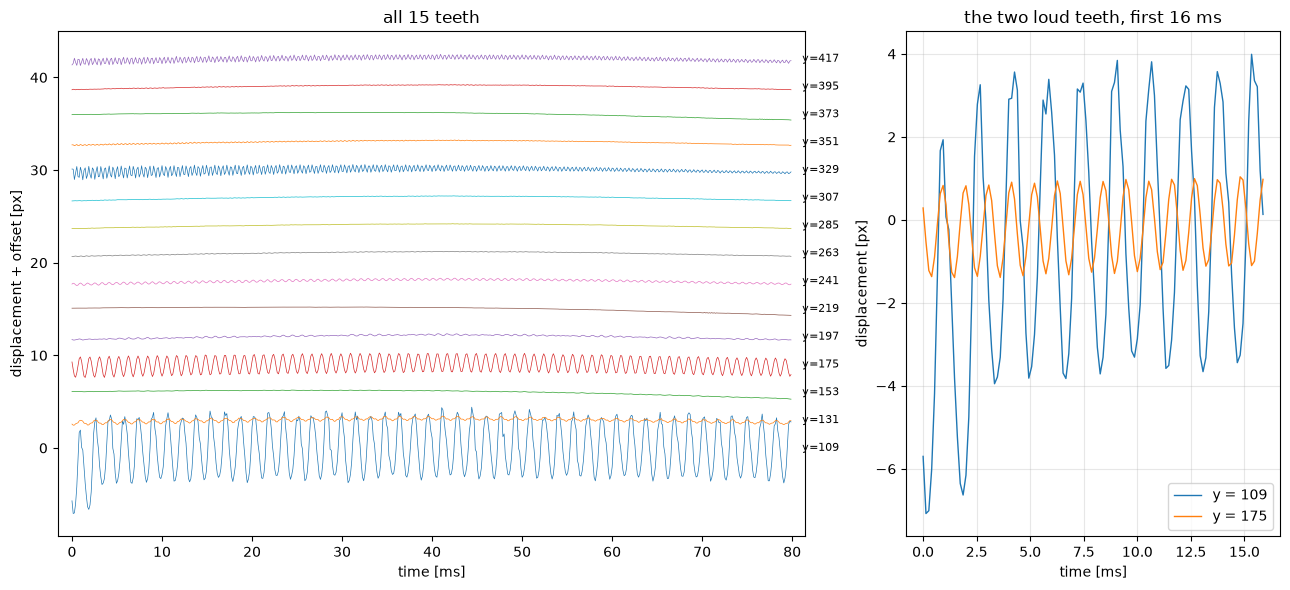

In [7]:
y = displacements[:, :, 0] - displacements[:, :, 0].mean(axis=1, keepdims=True)
time = np.arange(video.N) / fps * 1000       # ms

fig, ax = plt.subplots(1, 2, figsize=(13, 6), width_ratios=(2, 1))
offset = 3.0
for i, row in enumerate(tooth_rows):
    ax[0].plot(time, y[i] + i * offset, lw=0.5)
    ax[0].text(time[-1] * 1.01, i * offset, f' y={row}', va='center', fontsize=8)
ax[0].set_xlabel('time [ms]'); ax[0].set_ylabel('displacement + offset [px]')
ax[0].set_title('all 15 teeth')
ax[0].margins(x=0.02)

window = slice(0, 120)
for i in (0, 3):
    ax[1].plot(time[window], y[i][window], lw=1, label=f'y = {tooth_rows[i]}')
ax[1].set_xlabel('time [ms]'); ax[1].set_ylabel('displacement [px]')
ax[1].set_title('the two loud teeth, first 16 ms')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

## 7. The note of every tooth

The amplitude spectrum of each displacement history gives the natural frequency of the
tooth. The frequency of the peak is refined by fitting a parabola through the logarithm of
the three points around it, which brings the resolution well below the 12.5 Hz spacing of
the spectral lines. Comparing it with the equal-tempered scale (A4 = 440 Hz) gives the note
and the deviation from it in cents (a semitone is 100 cents).

In [8]:
def amplitude_spectrum(signal, fs):
    """Single-sided amplitude spectrum of the rows of ``signal``, in the units of ``signal``."""
    signal = signal - signal.mean(axis=-1, keepdims=True)
    window = np.hanning(signal.shape[-1])
    amplitude = np.abs(np.fft.rfft(signal * window, axis=-1)) * 2 / window.sum()
    return np.fft.rfftfreq(signal.shape[-1], 1 / fs), amplitude


def peak(frequency, amplitude, above=300.):
    """Frequency and amplitude of the highest peak above ``above``, with parabolic refinement."""
    first = np.searchsorted(frequency, above)
    k = first + np.argmax(amplitude[first:])
    left, centre, right = np.log(amplitude[k - 1:k + 2])
    delta = 0.5 * (left - right) / (left - 2 * centre + right)
    return (k + delta) * (frequency[1] - frequency[0]), amplitude[k]


NOTES = 'C C# D D# E F F# G G# A A# B'.split()

def nearest_note(frequency, a4=440.):
    """Nearest equal-tempered note and the deviation from it in cents."""
    midi = 12 * np.log2(frequency / a4) + 69
    k = int(round(midi))
    return f'{NOTES[k % 12]}{k // 12 - 1}', (midi - k) * 100

In [9]:
frequency, amplitude = amplitude_spectrum(y, fps)

print(f'{"y [px]":>7} {"f [Hz]":>9} {"amplitude [px]":>15} {"note":>6} {"deviation":>10}')
peaks = []
for i, row in enumerate(tooth_rows):
    f_peak, a_peak = peak(frequency, amplitude[i])
    note, cents = nearest_note(f_peak)
    peaks.append((f_peak, a_peak))
    quiet = '' if a_peak > 0.02 else '   (not plucked in this window)'
    print(f'{row:7d} {f_peak:9.1f} {a_peak:15.3f} {note:>6} {cents:+9.0f} c{quiet}')
peaks = np.array(peaks)

 y [px]    f [Hz]  amplitude [px]   note  deviation
    109     621.2           3.352    D#5        -3 c
    131     621.3           0.169    D#5        -3 c
    153     931.9           0.016    A#5        -1 c   (not plucked in this window)
    175     931.9           0.918    A#5        -1 c
    197    1048.6           0.044     C6        +3 c
    219     620.7           0.005    D#5        -4 c   (not plucked in this window)
    241    1251.1           0.115    D#6        +9 c
    263    1577.2           0.018     G6       +10 c   (not plucked in this window)
    285    2001.0           0.006     B6       +22 c   (not plucked in this window)
    307    2022.8           0.007     B6       +41 c   (not plucked in this window)
    329    2217.1           0.348    C#7        -0 c
    351    2215.9           0.032    C#7        -1 c
    373     622.3           0.006    D#5        +0 c   (not plucked in this window)
    395    2214.4           0.012    C#7        -2 c   (not plucked in th

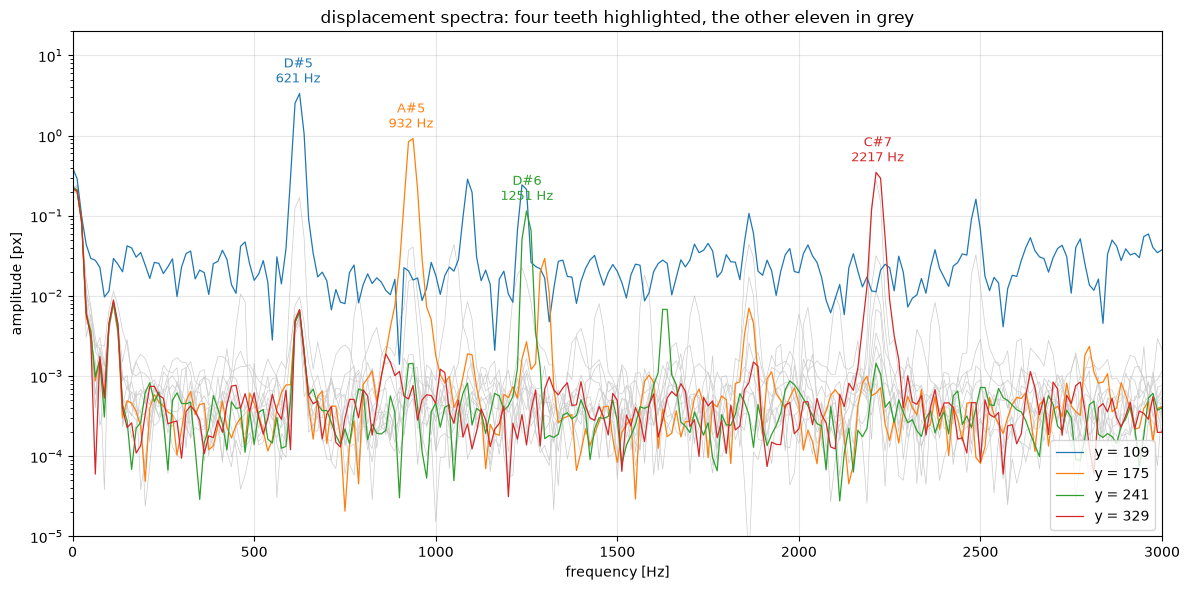

In [10]:
highlight = [109, 175, 241, 329]

fig, ax = plt.subplots(figsize=(12, 6))
for i, row in enumerate(tooth_rows):
    if row not in highlight:
        ax.semilogy(frequency, amplitude[i], lw=0.5, color='0.8', zorder=1)
for row in highlight:
    i = int(np.where(tooth_rows == row)[0][0])
    line, = ax.semilogy(frequency, amplitude[i], lw=0.9, zorder=2, label=f'y = {row}')
    f_peak, a_peak = peaks[i]
    note, cents = nearest_note(f_peak)
    ax.annotate(f'{note}\n{f_peak:.0f} Hz', (f_peak, a_peak), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color=line.get_color())

ax.set_xlim(0, 3000)
ax.set_ylim(1e-5, 2e1)
ax.set_xlabel('frequency [Hz]'); ax.set_ylabel('amplitude [px]')
ax.set_title('displacement spectra: four teeth highlighted, the other eleven in grey')
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()

Read from a video, without touching the instrument, the identified frequencies land
within a few cents of equal-tempered pitches. Neighbouring teeth sometimes share a
frequency — the comb carries duplicated notes — and the teeth that are not plucked in this
window respond weakly at the frequencies of their loud neighbours.

The amplitudes span three orders of magnitude, from about 3 px down to a few thousandths
of a pixel, all from the same recording and the same analysis.

## 8. The deflection shape of a single tooth

Points along one tooth measure its operating deflection shape. The tooth at `y = 175`
vibrates well below one pixel over its whole length, which makes it a good test of the
sub-pixel resolution: near the root the amplitude is a few hundredths of a pixel, at the
free end it is about one pixel.

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.00 s


Time to complete: 0.6 s


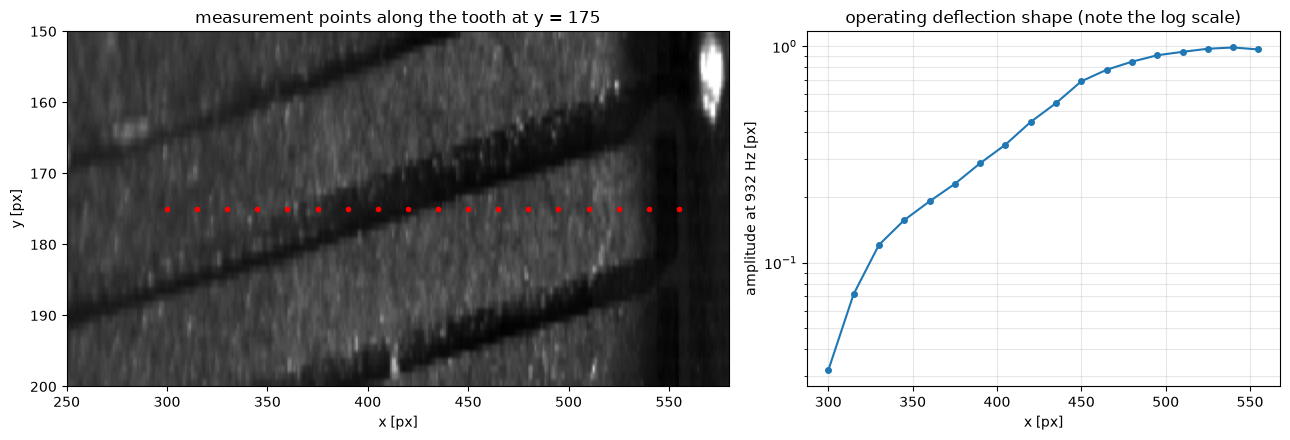

In [11]:
tooth = 175
columns = np.arange(300, 561, 15)
line_points = np.array([[tooth, c] for c in columns])

line = pyidi.LucasKanade(video)
line.set_points(line_points)
line.configure(roi_size=roi_size, pad=3, int_order=3, reference_image=0, show_pbar=False)
line_displacements = line.get_displacements(autosave=False)

line_frequency, line_amplitude = amplitude_spectrum(line_displacements[:, :, 0], fps)
tooth_frequency = peaks[np.where(tooth_rows == tooth)[0][0], 0]
k = np.argmin(np.abs(line_frequency - tooth_frequency))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), width_ratios=(1.4, 1))
ax[0].imshow(reference[tooth - 25:tooth + 25, 250:580], cmap='gray', aspect='auto',
             extent=(250, 580, tooth + 25, tooth - 25))
ax[0].plot(line_points[:, 1], line_points[:, 0], 'r.', ms=6)
ax[0].set_title(f'measurement points along the tooth at y = {tooth}')
ax[0].set_xlabel('x [px]'); ax[0].set_ylabel('y [px]')

ax[1].plot(columns, line_amplitude[:, k], 'o-', ms=4)
ax[1].set_yscale('log')
ax[1].set_xlabel('x [px]')
ax[1].set_ylabel(f'amplitude at {tooth_frequency:.0f} Hz [px]')
ax[1].set_title('operating deflection shape (note the log scale)')
ax[1].grid(alpha=0.3, which='both')
plt.tight_layout()

The amplitude grows smoothly from the root to the free end over more than an order of
magnitude — the first bending shape of a cantilever, measured optically, entirely within
one pixel of the image.

## 9. A second method on the same data

The teeth move along one direction only, which `DirectionalLucasKanade` can be told:
`dij=(1, 0)` constrains the identification to the vertical direction, leaving a single
unknown per point instead of two.

In [12]:
directional = pyidi.DirectionalLucasKanade(video)
directional.set_points(points)
directional.configure(roi_size=roi_size, dij=(1, 0), pad=(3, 3), int_order=3,
                      reference_image=0, show_pbar=False)
directional_displacements = directional.get_displacements(autosave=False)

_, directional_amplitude = amplitude_spectrum(directional_displacements[:, :, 0], fps)

print(f'{"y [px]":>7} {"Lucas-Kanade":>14} {"directional LK":>16} {"difference":>12}')
for i, row in enumerate(tooth_rows[:6]):
    a_lk = peaks[i, 1]
    a_dlk = peak(frequency, directional_amplitude[i])[1]
    print(f'{row:7d} {a_lk:11.3f} px {a_dlk:13.3f} px {100 * (a_dlk - a_lk) / a_lk:9.1f} %')

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.00 s


Time to complete: 0.4 s
 y [px]   Lucas-Kanade   directional LK   difference
    109       3.352 px         3.535 px       5.5 %
    131       0.169 px         0.178 px       5.4 %
    153       0.016 px         0.017 px       1.2 %
    175       0.918 px         0.947 px       3.1 %
    197       0.044 px         0.047 px       6.5 %
    219       0.005 px         0.005 px       1.2 %


The two methods agree to within a few percent. The constrained method is not
simply a cheaper Lucas-Kanade: prescribing the direction of the motion regularizes the
problem, which helps where the texture is poor or the amplitude is at the resolution
limit, and biases the result where the motion is not along the prescribed direction after
all.

## 10. Where to go from here

* `pyidi.datasets.load_music_box(n_frames=..., first_frame=...)` reads any window of the
  published 3000-frame excerpt. `first_frame=0` includes the pluck of the loud tooth, where
  the motion exceeds 10 px between consecutive frames — a hard case for any local method,
  and a good one to test a method against.
* The Zenodo record also holds the full 36 GiB recording (55 238 frames, 7.4 s), in which
  every tooth of the comb is plucked. With that recording the whole scale can be read out,
  and the ring-down is long enough for damping identification.
* Points can also be selected interactively, see
  [the documentation](https://pyidi.readthedocs.io/en/latest/quick_start/napari.html).

If you use the dataset, please cite it:

> Stanovnik, G., & Slavič, J. (2026). *High-speed video of a vibrating music-box comb
> (Photron FASTCAM SA-Z, 7500 fps, 640x552 px)* [Data set]. Zenodo.
> https://doi.org/10.5281/zenodo.22105821

The recording was made at the Laboratory for Dynamics of Machines and Structures
([LADISK](https://www.ladisk.si)), Faculty of Mechanical Engineering, University of
Ljubljana. The authors acknowledge the financial support of the Slovenian Research and
Innovation Agency (ARIS), research core funding No. P2-0263.